In [1]:
from microhh.python.plot_microhh_utils import load_xy, load_3d, get_local_start, plot_domain_mean, plot_cross_sections, plot_flux_sections
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

# data_dir = "/pscratch/sd/m/mpowell/CASS_LES_2stream/"
# start_local = get_local_start(data_dir)
# TIME_VAL = start_local + pd.Timedelta(hours=10)
# print(f"Start (local): {start_local}")
# print(f"TIME_VAL:      {TIME_VAL}")

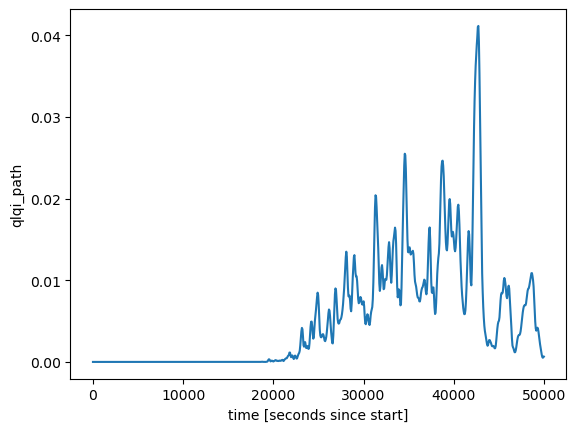

In [4]:
ds = xr.open_dataset("/pscratch/sd/m/mpowell/CASS_LES/debug/soil_moisture/theta_0p1/2stream/rep_01/qlqi_path.xy.nc", decode_times = False)
ds.qlqi_path.mean(['x', 'y']).plot()

In [2]:
ds_xy = load_xy("/pscratch/sd/m/mpowell/CASS_LES_2stream/")
ds = load_3d("/pscratch/sd/m/mpowell/CASS_LES_2stream/")
half_idx = int(len(ds_xy.x.values)/2)

In [ ]:
# (ds.ql.mean(['x', 'y'])*1000*1e3).plot(y = 'z')
# plt.tight_layout()

In [ ]:
plot_domain_mean(ds_xy)
plot_cross_sections(ds, ds_xy, time = TIME_VAL, yidx=half_idx, xidx=half_idx, qv_vmin = 0.008, zmax=3500)
plot_flux_sections(ds, ds_xy, time = TIME_VAL, yidx=half_idx, xidx=half_idx)

In [3]:
ds_xy_rt = load_xy("/pscratch/sd/m/mpowell/CASS_LES_raytracer/")
# ds_rt = load_3d("/pscratch/sd/m/mpowell/CASS_LES_raytracer/")

half_idx = int(len(ds_xy_rt.x.values)/2)

<Axes: xlabel='time', ylabel='qlqi_path'>

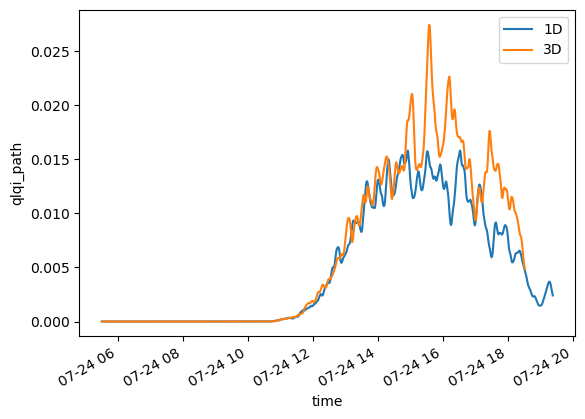

In [4]:
plot_domain_mean(ds_xy, var="qlqi_path", ds_xy2=ds_xy_rt, label="1D", label2="3D")

In [ ]:
ds_xy_rt['sw_flux_dn_rt'] = ds_xy_rt.sw_flux_sfc_dif_rt + ds_xy_rt.sw_flux_sfc_dir_rt

plot_cross_sections(ds_rt, ds_xy_rt, time = TIME_VAL, yidx=half_idx, xidx=half_idx, qv_vmin = 0.008, zmax=3500, flux_var_name = 'sw_flux_dn_rt')
plot_flux_sections(ds_rt, ds_xy_rt, time = TIME_VAL, yidx=half_idx, xidx=half_idx)

In [ ]:
ds_xy['cc'] = ds_xy['qlqi_path'] > 0
ds_xy_rt['cc'] = ds_xy_rt['qlqi_path'] > 0

plot_domain_mean(ds_xy, var="cc", ds_xy2=ds_xy_rt, label="1D", label2="3D")
plot_domain_mean(ds_xy, var="b", ds_xy2=ds_xy_rt, label="1D", label2="3D")
plot_domain_mean(ds_xy, var="sw_flux_dn", ds_xy2=ds_xy_rt, label="1D", label2="3D")
plot_domain_mean(ds_xy, var="qlqi_top", ds_xy2=ds_xy_rt, label="1D", label2="3D")
plot_domain_mean(ds_xy, var="thl_fluxbot", ds_xy2=ds_xy_rt, label="1D", label2="3D")

In [ ]:
plot_domain_mean(ds_xy, var="qlqi_base", ds_xy2=ds_xy_rt, label="1D", label2="3D")

In [ ]:
fig, axs = plt.subplots(2, 3, figsize = (16, 10))

ds_xy.sw_flux_dn.sel(time=TIME_VAL).plot(ax = axs[0][0])
((ds_xy.qlqi_path > 0).astype(float)).sel(time=TIME_VAL).plot.contour(ax = axs[0][0],
    levels=[0.5], colors="black", linewidths=1.5
)
axs[0][0].set_title("")
(ds_xy.thl_fluxbot.sel(time=TIME_VAL)).plot(ax = axs[0][1])
((ds_xy.qlqi_path > 0).astype(float)).sel(time=TIME_VAL).plot.contour(ax = axs[0][1],
    levels=[0.5], colors="black", linewidths=1.5
)
axs[0][1].set_title("1D")

ds_xy.qt_fluxbot.sel(time=TIME_VAL).plot(ax = axs[0][2])
((ds_xy.qlqi_path > 0).astype(float)).sel(time=TIME_VAL).plot.contour(ax = axs[0][2],
    levels=[0.5], colors="black", linewidths=1.5
)
axs[0][2].set_title("")



ds_xy_rt.sw_flux_dn_rt.sel(time=TIME_VAL).plot(ax = axs[1][0])
((ds_xy_rt.qlqi_path > 0).astype(float)).sel(time=TIME_VAL).plot.contour(ax = axs[1][0],
    levels=[0.5], colors="black", linewidths=1.5
)
axs[1][0].set_title("")
(ds_xy_rt.thl_fluxbot.sel(time=TIME_VAL)).plot(ax = axs[1][1])
((ds_xy_rt.qlqi_path > 0).astype(float)).sel(time=TIME_VAL).plot.contour(ax = axs[1][1],
    levels=[0.5], colors="black", linewidths=1.5
)
axs[1][1].set_title("3D")
ds_xy_rt.qt_fluxbot.sel(time=TIME_VAL).plot(ax = axs[1][2])
((ds_xy_rt.qlqi_path > 0).astype(float)).sel(time=TIME_VAL).plot.contour(ax = axs[1][2],
    levels=[0.5], colors="black", linewidths=1.5
)
axs[1][2].set_title("")

plt.tight_layout()
plt.show()

In [ ]:
da_diff = (ds_xy_rt.qlqi_path.mean(['x', 'y']) - ds_xy.isel(time = slice(None, 783)).qlqi_path.mean(['x', 'y']))

In [ ]:
da_diff = da_diff.load()

In [ ]:
fig, ax = plt.subplots(figsize = (10, 5))
(da_diff.rolling(time=60, center=True).mean()*1000).plot(ax = ax)
plt.tight_layout()